         ts_s  loss_rate
0  1776703897   0.000000
1  1776703898   0.004310
2  1776703899   0.046129
3  1776703900   0.060709
4  1776703901   0.056235


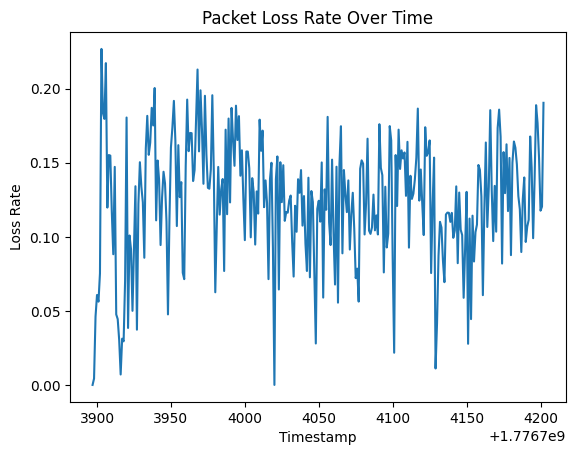

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("stats.csv")

# Compute loss rate: lost / (pkts + lost)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"])

# Group by timestamp and compute average loss rate
loss_rate_per_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

print(loss_rate_per_time.head())


loss_rate_per_time.to_csv("loss_rate_per_time.csv", index=False)

# Plot (optional)
import matplotlib.pyplot as plt
plt.plot(loss_rate_per_time["ts_s"], loss_rate_per_time["loss_rate"])
plt.xlabel("Timestamp")
plt.ylabel("Loss Rate")
plt.title("Packet Loss Rate Over Time")
plt.show()



# this zoom packet had the zoom running for some time 



In [1]:
#!/usr/bin/env python3
"""
Phase 2: Complete Measurement Deep Dive Analysis
- Adaptation & Recovery Latency
- Mode Sensitivity (Screen Share vs Video)
- Correlation Tables

Author: Zoom Analysis Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ADAPTATION & RECOVERY LATENCY ANALYSIS
# ============================================================================

def detect_loss_events(df, loss_threshold=0.05, min_duration=2):
    """
    Detect packet loss events (periods when loss > threshold).
    
    Args:
        df: DataFrame with 'ts_s' and 'loss_rate' columns
        loss_threshold: Loss rate threshold to trigger event (default: 5%)
        min_duration: Minimum consecutive seconds for valid event
        
    Returns:
        List of tuples: (event_start_ts, event_end_ts, duration, max_loss)
    """
    events = []
    in_event = False
    event_start = None
    max_loss_in_event = 0
    event_losses = []
    
    for idx, row in df.iterrows():
        ts = row['ts_s']
        loss = row['loss_rate']
        
        if loss > loss_threshold and not in_event:
            # Event starts
            in_event = True
            event_start = ts
            max_loss_in_event = loss
            event_losses = [loss]
            
        elif loss > loss_threshold and in_event:
            # Event continues
            max_loss_in_event = max(max_loss_in_event, loss)
            event_losses.append(loss)
            
        elif loss <= loss_threshold and in_event:
            # Event ends
            event_end = ts
            duration = event_end - event_start
            
            if duration >= min_duration:  # Only count sustained events
                events.append({
                    'start_ts': event_start,
                    'end_ts': event_end,
                    'duration': duration,
                    'max_loss': max_loss_in_event,
                    'avg_loss': np.mean(event_losses)
                })
            
            in_event = False
            event_start = None
            max_loss_in_event = 0
    
    return events


def calculate_fps_drop_latency(df, loss_events):
    """
    For each loss event, calculate reaction time: time from loss START to FPS DROP.
    
    Args:
        df: DataFrame with 'ts_s', 'loss_rate', 'frames' columns
        loss_events: List of loss event dicts
        
    Returns:
        List of reaction latencies in seconds
    """
    reaction_latencies = []
    fps_threshold_drop = 15  # FPS dropping below 15 = quality issue
    
    for event in loss_events:
        event_start = event['start_ts']
        event_end = event['end_ts']
        
        # Get data points AFTER loss starts
        after_loss = df[df['ts_s'] >= event_start].copy()
        after_loss = after_loss[after_loss['ts_s'] <= event_start + 5]  # Look 5 sec ahead
        
        if len(after_loss) == 0:
            continue
        
        # Find first point where FPS drops
        baseline_fps = df[df['ts_s'] < event_start]['frames'].mean()
        
        for idx, row in after_loss.iterrows():
            if row['frames'] < fps_threshold_drop or row['frames'] < baseline_fps * 0.5:
                reaction_time = row['ts_s'] - event_start
                reaction_latencies.append({
                    'event_start': event_start,
                    'fps_drop_ts': row['ts_s'],
                    'reaction_latency_sec': reaction_time,
                    'baseline_fps': baseline_fps,
                    'observed_fps': row['frames']
                })
                break
    
    return reaction_latencies


def calculate_recovery_latency(df, loss_events):
    """
    For each loss event, calculate recovery time: time from loss END to QoE > 0.9.
    
    Args:
        df: DataFrame with 'ts_s', 'loss_rate', 'qoe_score' columns
        loss_events: List of loss event dicts
        
    Returns:
        List of recovery latencies in seconds
    """
    recovery_latencies = []
    qoe_recovery_target = 0.9
    
    for event in loss_events:
        event_end = event['end_ts']
        
        # Get data points AFTER loss ends
        after_recovery = df[df['ts_s'] >= event_end].copy()
        after_recovery = after_recovery[after_recovery['ts_s'] <= event_end + 10]  # Look 10 sec ahead
        
        if len(after_recovery) == 0:
            continue
        
        # Find first point where QoE recovers above threshold
        for idx, row in after_recovery.iterrows():
            if row['qoe_score'] >= qoe_recovery_target:
                recovery_time = row['ts_s'] - event_end
                recovery_latencies.append({
                    'event_end': event_end,
                    'qoe_recovery_ts': row['ts_s'],
                    'recovery_latency_sec': recovery_time,
                    'recovered_qoe': row['qoe_score']
                })
                break
    
    return recovery_latencies


def analyze_adaptation_latency(df):
    """
    Main function for adaptation & recovery latency analysis.
    """
    print("\n" + "="*70)
    print("PHASE 2.1: ADAPTATION & RECOVERY LATENCY ANALYSIS")
    print("="*70)
    
    # Detect loss events
    loss_events = detect_loss_events(df, loss_threshold=0.05, min_duration=2)
    print(f"\n📊 Detected {len(loss_events)} packet loss events (>5% loss for ≥2 seconds)")
    
    if len(loss_events) == 0:
        print("⚠️  No significant loss events detected.")
        return None, None
    
    # Calculate reaction latencies
    reactions = calculate_fps_drop_latency(df, loss_events)
    print(f"\n⏱️  Reaction Latencies (Loss → FPS Drop): {len(reactions)} events")
    
    if reactions:
        reaction_times = [r['reaction_latency_sec'] for r in reactions]
        print(f"   Mean Reaction Time: {np.mean(reaction_times):.2f}s")
        print(f"   Median Reaction Time: {np.median(reaction_times):.2f}s")
        print(f"   P95 Reaction Time: {np.percentile(reaction_times, 95):.2f}s")
    
    # Calculate recovery latencies
    recoveries = calculate_recovery_latency(df, loss_events)
    print(f"\n🔄 Recovery Latencies (Loss Stop → QoE >0.9): {len(recoveries)} events")
    
    if recoveries:
        recovery_times = [r['recovery_latency_sec'] for r in recoveries]
        print(f"   Mean Recovery Time: {np.mean(recovery_times):.2f}s")
        print(f"   Median Recovery Time: {np.median(recovery_times):.2f}s")
        print(f"   P95 Recovery Time: {np.percentile(recovery_times, 95):.2f}s")
    
    return reactions, recoveries


# ============================================================================
# 2. MODE SENSITIVITY ANALYSIS (Screen Share vs Video)
# ============================================================================

def load_multiple_scenarios(scenario_paths):
    """
    Load and combine multiple scenario CSVs.
    
    Args:
        scenario_paths: Dict with mode names as keys and file paths as values
        
    Returns:
        Dict with mode names as keys and DataFrames as values
    """
    scenarios = {}
    
    for mode_name, csv_path in scenario_paths.items():
        try:
            df = pd.read_csv(csv_path)
            df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
            
            # Calculate QoE if not present
            if 'qoe_score' not in df.columns:
                w1, w2, w3 = 0.4, 0.3, 0.3
                df['loss_rate'] = df['lost'] / (df['pkts'] + df['lost'] + 1e-10)
                df['loss_rate'] = df['loss_rate'].clip(0, 1)
                
                if 'bytes' in df.columns:
                    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6
                    
                if 'mean_jitter' in df.columns:
                    df['jitter_ms'] = df['mean_jitter'] * 1000
                
                df['fps_norm'] = (df['frames'] / 30).clip(0, 1)
                df['jitter_norm'] = (1 - (df['jitter_ms'] / 40)).clip(0, 1)
                
                df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + \
                                  (w2 * df['fps_norm']) + \
                                  (w3 * df['jitter_norm'])
            
            scenarios[mode_name] = df
            print(f"✓ Loaded {mode_name}: {len(df)} records")
            
        except FileNotFoundError:
            print(f"✗ Not found: {csv_path}")
        except Exception as e:
            print(f"✗ Error loading {mode_name}: {str(e)}")
    
    return scenarios


def analyze_mode_sensitivity(scenarios):
    """
    Compare metrics across different modes (Screen Share vs Video).
    """
    print("\n" + "="*70)
    print("PHASE 2.2: MODE SENSITIVITY ANALYSIS (Screen Share vs Video)")
    print("="*70)
    
    if len(scenarios) < 2:
        print("⚠️  Need at least 2 scenarios for comparison. Skipping mode analysis.")
        return None
    
    # Summary statistics by mode
    summary = {}
    metrics = ['qoe_score', 'loss_rate', 'frames', 'jitter_ms', 'bitrate_mbps']
    
    for mode_name, df in scenarios.items():
        print(f"\n📊 {mode_name} Mode Statistics:")
        print("-" * 50)
        
        mode_summary = {}
        for metric in metrics:
            if metric in df.columns:
                values = df[metric].dropna()
                if len(values) > 0:
                    mode_summary[metric] = {
                        'mean': values.mean(),
                        'median': values.median(),
                        'std': values.std(),
                        'min': values.min(),
                        'max': values.max(),
                        'p95': values.quantile(0.95)
                    }
                    print(f"  {metric:15s}: μ={values.mean():.3f}, σ={values.std():.3f}, "
                          f"[{values.min():.3f}, {values.max():.3f}]")
        
        summary[mode_name] = mode_summary
    
    # Identify "Brittleness" - which mode breaks faster under loss?
    print("\n🔨 MODE BRITTLENESS ANALYSIS (QoE sensitivity to loss):")
    print("-" * 50)
    
    brittleness = {}
    for mode_name, df in scenarios.items():
        # Calculate correlation: loss_rate → qoe_score
        if 'loss_rate' in df.columns and 'qoe_score' in df.columns:
            high_loss_events = df[df['loss_rate'] > 0.1]
            
            if len(high_loss_events) > 0:
                avg_qoe_under_loss = high_loss_events['qoe_score'].mean()
                qoe_drop_ratio = 1.0 - (avg_qoe_under_loss / df['qoe_score'].mean())
                
                brittleness[mode_name] = {
                    'qoe_under_loss': avg_qoe_under_loss,
                    'qoe_drop_ratio': qoe_drop_ratio,
                    'events_with_loss': len(high_loss_events)
                }
                
                print(f"  {mode_name}:")
                print(f"    - QoE under high loss (>10%): {avg_qoe_under_loss:.3f}")
                print(f"    - QoE degradation ratio: {qoe_drop_ratio:.1%}")
                print(f"    - High-loss events: {len(high_loss_events)}")
    
    # Identify which prioritizes what
    print("\n💡 HYPOTHESIS VALIDATION:")
    print("-" * 50)
    for mode_name, df in scenarios.items():
        if 'frames' in df.columns and 'bitrate_mbps' in df.columns:
            avg_fps = df['frames'].mean()
            avg_bitrate = df['bitrate_mbps'].mean()
            print(f"  {mode_name}: FPS={avg_fps:.1f}, Bitrate={avg_bitrate:.2f}Mbps")
    
    return summary, brittleness


# ============================================================================
# 3. CORRELATION ANALYSIS
# ============================================================================

def calculate_correlation_matrix(df):
    """
    Calculate Pearson correlation matrix: Jitter, Loss, FPS → QoE.
    """
    print("\n" + "="*70)
    print("PHASE 2.3: CORRELATION MATRIX ANALYSIS")
    print("="*70)
    
    # Select relevant columns
    analysis_cols = ['loss_rate', 'jitter_ms', 'frames', 'qoe_score']
    available_cols = [col for col in analysis_cols if col in df.columns]
    
    if len(available_cols) < 3:
        print("⚠️  Insufficient columns for correlation analysis.")
        return None
    
    # Create correlation matrix
    corr_matrix = df[available_cols].corr()
    
    print("\n📊 PEARSON CORRELATION MATRIX:")
    print("-" * 50)
    print(corr_matrix.round(3))
    
    # Identify strongest predictors of QoE
    print("\n🎯 STRONGEST PREDICTORS OF QoE:")
    print("-" * 50)
    
    if 'qoe_score' in corr_matrix.columns:
        qoe_correlations = corr_matrix['qoe_score'].drop('qoe_score').abs().sort_values(ascending=False)
        for metric, corr_val in qoe_correlations.items():
            correlation = corr_matrix.loc[metric, 'qoe_score']
            print(f"  {metric:15s}: {correlation:+.3f} (|r|={corr_val:.3f})")
    
    # Identify "bad call" threshold (QoE < 0.5)
    print("\n🚨 BAD CALL ANALYSIS (QoE < 0.5):")
    print("-" * 50)
    
    bad_calls = df[df['qoe_score'] < 0.5]
    good_calls = df[df['qoe_score'] >= 0.5]
    
    print(f"  Bad calls: {len(bad_calls)} / {len(df)} ({len(bad_calls)/len(df)*100:.1f}%)")
    
    if len(bad_calls) > 0:
        print("\n  Metrics during bad calls vs good calls:")
        for metric in available_cols:
            if metric != 'qoe_score':
                bad_mean = bad_calls[metric].mean()
                good_mean = good_calls[metric].mean()
                print(f"    {metric:15s}: bad={bad_mean:.3f}, good={good_mean:.3f}")
    
    return corr_matrix


def visualize_correlations(df, output_path='correlation_heatmap.png'):
    """
    Create correlation heatmap visualization.
    """
    analysis_cols = ['loss_rate', 'jitter_ms', 'frames', 'qoe_score']
    available_cols = [col for col in analysis_cols if col in df.columns]
    
    if len(available_cols) < 3:
        print("⚠️  Insufficient columns for visualization.")
        return
    
    plt.figure(figsize=(8, 6))
    corr_matrix = df[available_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, 
                cbar_kws={'label': 'Pearson Correlation'})
    
    plt.title('Correlation Matrix: Network Metrics vs QoE', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved correlation heatmap: {output_path}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase2_analysis(data_dir='./data'):
    """
    Run complete Phase 2 analysis.
    
    Args:
        data_dir: Path to data directory containing scenario folders
    """
    
    # *** CONFIGURE YOUR DATA PATHS HERE ***
    # Modify these paths to match your actual data structure
    scenario_paths = {
        'Video (Default)': 'data/run_default/detailed_qoe_results.csv',
        'Screen Share': 'data/run_wifi_screen_share/stats.csv',
    }
    
    print("\n" + "="*70)
    print("ZOOM ANALYSIS - PHASE 2: MEASUREMENT DEEP DIVE")
    print("="*70)
    
    # Load primary dataset
    print("\n📂 Loading primary dataset...")
    try:
        df = pd.read_csv('data/run_default/detailed_qoe_results.csv')
        print(f"✓ Loaded {len(df)} records")
    except FileNotFoundError:
        print("✗ Primary dataset not found. Check data path.")
        return
    
    # 1. ADAPTATION & RECOVERY LATENCY
    reactions, recoveries = analyze_adaptation_latency(df)
    
    # 2. MODE SENSITIVITY
    scenarios = load_multiple_scenarios(scenario_paths)
    summary, brittleness = analyze_mode_sensitivity(scenarios)
    
    # 3. CORRELATION ANALYSIS
    corr_matrix = calculate_correlation_matrix(df)
    visualize_correlations(df)
    
    # 4. SAVE SUMMARY REPORTS
    print("\n" + "="*70)
    print("SAVING RESULTS")
    print("="*70)
    
    if reactions:
        reactions_df = pd.DataFrame(reactions)
        reactions_df.to_csv('adaptation_reaction_latency.csv', index=False)
        print("✓ Saved: adaptation_reaction_latency.csv")
    
    if recoveries:
        recoveries_df = pd.DataFrame(recoveries)
        recoveries_df.to_csv('adaptation_recovery_latency.csv', index=False)
        print("✓ Saved: adaptation_recovery_latency.csv")
    
    if corr_matrix is not None:
        corr_matrix.to_csv('correlation_matrix.csv')
        print("✓ Saved: correlation_matrix.csv")
    
    print("\n✅ Phase 2 analysis complete!")


if __name__ == "__main__":
    run_phase2_analysis()



ZOOM ANALYSIS - PHASE 2: MEASUREMENT DEEP DIVE

📂 Loading primary dataset...
✗ Primary dataset not found. Check data path.
